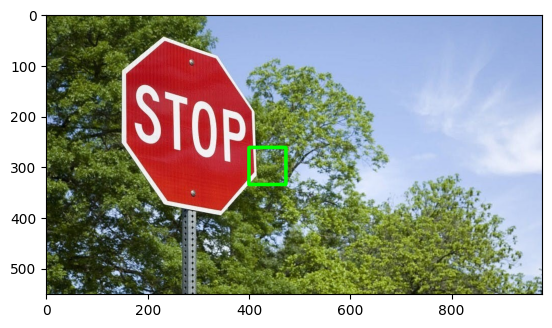

In [3]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread("image.jpg")
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# dots that would look like STOP signs
stop_data = cv2.CascadeClassifier('/content/haarcascade_frontalface_default.xml')
#('/content/haarcascade_frontalcatface.xml')
found = stop_data.detectMultiScale(img_gray,minSize =(20, 20))
amount_found = len(found)

if amount_found != 0:
    for (x, y, width, height) in found:
        cv2.rectangle(img_rgb, (x, y),
                      (x + height, y + width),
                      (0, 255, 0), 5)
plt.imshow(img_rgb)



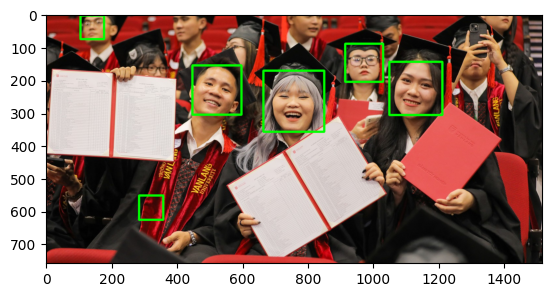

In [4]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread("hinh2.jpg")
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# dots that would look like STOP signs
stop_data = cv2.CascadeClassifier('/content/haarcascade_frontalface_default.xml')
#('/content/haarcascade_frontalcatface.xml')
found = stop_data.detectMultiScale(img_gray,minSize =(20, 20))
amount_found = len(found)

if amount_found != 0:
    for (x, y, width, height) in found:
        cv2.rectangle(img_rgb, (x, y),
                      (x + height, y + width),
                      (0, 255, 0), 5)
plt.imshow(img_rgb)



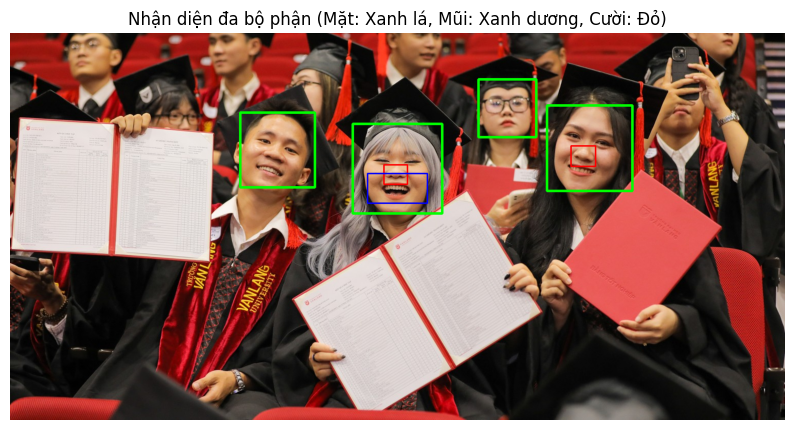

In [12]:
import cv2
import matplotlib.pyplot as plt

# 1. Đọc ảnh và chuẩn bị
img = cv2.imread('hinh2.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2. Tải các bộ phân loại
face_cascade = cv2.CascadeClassifier('/content/haarcascade_frontalface_default.xml')
nose_cascade = cv2.CascadeClassifier('/content/haarcascade_mcs_nose.xml')
smile_cascade = cv2.CascadeClassifier('/content/haarcascade_smile.xml')

# 3. Nhận diện khuôn mặt
faces = face_cascade.detectMultiScale(img_gray, 1.3, 5)

for (x, y, w, h) in faces:
    # Vẽ khung cho khuôn mặt (Màu xanh lá)
    cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 255, 0), 3)

    # Vùng quan tâm (ROI) - chỉ tìm mũi và miệng trong khuôn mặt để chính xác hơn
    roi_gray = img_gray[y:y+h, x:x+w]
    roi_color = img_rgb[y:y+h, x:x+w]

    # 4. Nhận diện mũi bên trong vùng khuôn mặt
    noses = nose_cascade.detectMultiScale(roi_gray, 1.1, 10, minSize=(30, 30))
    for (nx, ny, nw, nh) in noses:
        cv2.rectangle(roi_color, (nx, ny), (nx + nw, ny + nh), (255, 0, 0), 2) # Màu xanh dương

    # 5. Nhận diện nụ cười bên trong vùng khuôn mặt
    smiles = smile_cascade.detectMultiScale(roi_gray, 1.8, 20, minSize=(25, 25))
    for (sx, sy, sw, sh) in smiles:
        cv2.rectangle(roi_color, (sx, sy), (sx + sw, sy + sh), (0, 0, 255), 2) # Màu đỏ

# Hiển thị kết quả
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Nhận diện đa bộ phận (Mặt: Xanh lá, Mũi: Xanh dương, Cười: Đỏ)')
plt.show()

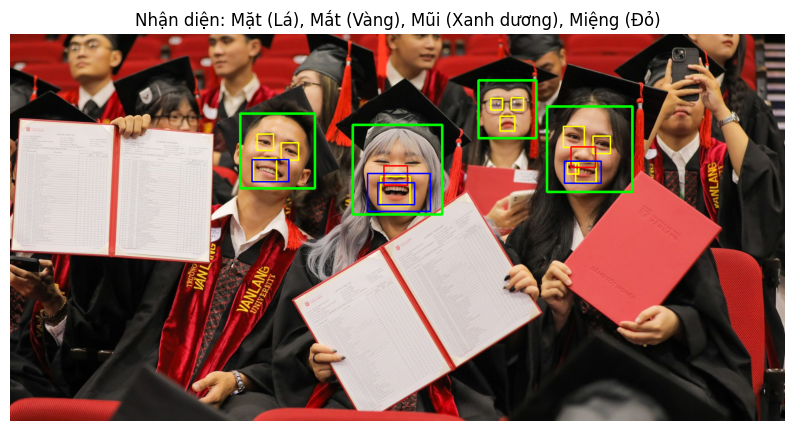

In [13]:
import cv2
import matplotlib.pyplot as plt

# 1. Đọc ảnh và chuẩn bị
img = cv2.imread('hinh2.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2. Tải các bộ phân loại
face_cascade = cv2.CascadeClassifier('/content/haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('/content/haarcascade_eye.xml')
nose_cascade = cv2.CascadeClassifier('/content/haarcascade_mcs_nose.xml')
mouth_cascade = cv2.CascadeClassifier('/content/haarcascade_mcs_mouth.xml')

# 3. Nhận diện khuôn mặt
faces = face_cascade.detectMultiScale(img_gray, 1.3, 5)

for (x, y, w, h) in faces:
    # Vẽ khung cho khuôn mặt (Màu xanh lá)
    cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 255, 0), 3)

    roi_gray = img_gray[y:y+h, x:x+w]
    roi_color = img_rgb[y:y+h, x:x+w]

    # 4. Nhận diện mắt (Màu vàng)
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (255, 255, 0), 2)

    # 5. Nhận diện mũi (Màu xanh dương)
    noses = nose_cascade.detectMultiScale(roi_gray, 1.1, 10, minSize=(30, 30))
    for (nx, ny, nw, nh) in noses:
        cv2.rectangle(roi_color, (nx, ny), (nx + nw, ny + nh), (255, 0, 0), 2)

    # 6. Nhận diện miệng (Màu đỏ)
    roi_mouth_gray = roi_gray[int(h/2):h, :]
    roi_mouth_color = roi_color[int(h/2):h, :]
    mouths = mouth_cascade.detectMultiScale(roi_mouth_gray, 1.7, 11)
    for (mx, my, mw, mh) in mouths:
        cv2.rectangle(roi_mouth_color, (mx, my), (mx + mw, my + mh), (0, 0, 255), 2)

# Hiển thị kết quả
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Nhận diện: Mặt (Lá), Mắt (Vàng), Mũi (Xanh dương), Miệng (Đỏ)')
plt.show()